# 01 — Data Exploration

Plot processed GeoTIFF tiles alongside their ground-truth YOLO OBB labels.
All logic is imported from ; this notebook contains no business logic.

In [74]:
# ── Standard library ──────────────────────────────────────────────────────
import sys
from pathlib import Path

# Add project root to path so src is importable when running from notebooks/
sys.path.insert(0, str(Path.cwd().parent))

# ── Third-party ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import rasterio
from matplotlib.collections import PatchCollection

# ── Project ───────────────────────────────────────────────────────────────
from src.vessels_detect.utils.config import load_config
from src.vessels_detect.utils.metrics import build_size_dataframe

plt.rcParams.update({
    "figure.dpi": 130,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
print("Imports OK.")

Imports OK.


## 1. Configuration

Change the paths below to match your environment.

In [75]:
from pathlib import Path

# 1. Hardcode your raw data directory
DATA_ROOT = Path("/home/thomas/Documents/code/pleiades-boat-detection/data/raw")

# 2. Hardcode your classes (Update these if your dataset.yaml has different names/IDs)
CLASS_NAMES = {
    0: 'Pirogue',
    1: 'Double hubble pirogue',
    2: 'Small Motorboat',
    3: 'Medium Motorboat',
    4: 'Ferry',
    5: 'Sailboat',
    6: 'Large Motorboat',
    8: 'Pirogue (Hard)',
    9: 'UNKNOWN',
    10: 'Rowboat',
    11: 'Fishing trap',

}

print(f"Data root directory : {DATA_ROOT}")
print(f"Dataset classes     : {CLASS_NAMES}")

Data root directory : /home/thomas/Documents/code/pleiades-boat-detection/data/raw
Dataset classes     : {0: 'Pirogue', 1: 'Double hubble pirogue', 2: 'Small Motorboat', 3: 'Medium Motorboat', 4: 'Ferry', 5: 'Sailboat', 6: 'Large Motorboat', 8: 'Pirogue (Hard)', 9: 'UNKNOWN', 10: 'Rowboat', 11: 'Fishing trap'}


## 2. Dataset Statistics

Per-class annotation counts across all splits.

In [76]:
import json
import pandas as pd
from collections import defaultdict

# We will manually count from .geojson files to bypass metrics.py's .txt requirement
counts = defaultdict(int)
geojson_files = list(DATA_ROOT.glob("*.geojson"))

for geo_path in geojson_files:
    with open(geo_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
        for feature in data.get('features', []):
            props = feature.get('properties', {})
            
            # Check for common geojson class keys ('class_id', 'id', or 'label')
            cid = props.get('class_id', props.get('id', props.get('label'))) 
            
            if cid is not None:
                counts[int(cid)] += 1

# Format into a DataFrame containing [Class ID, Class, Total]
rows = []
for cid, count in counts.items():
    rows.append({
        "Class ID": cid,
        "Class": CLASS_NAMES.get(cid, f"Unknown ({cid})"),
        "Total": count
    })

df_dist = pd.DataFrame(rows)

# Explicitly reorder columns to ensure [class id, class, total] layout
df_dist = df_dist[["Class ID", "Class", "Total"]]

# Sort the DataFrame by Class ID
df_dist = df_dist.sort_values(by="Class ID").reset_index(drop=True)

print(f"Found {len(geojson_files)} GeoJSON files.")
print("Object counts per class:")

# Print the DataFrame without the line numbers (index)
print(df_dist.to_string(index=False))

Found 13 GeoJSON files.
Object counts per class:
 Class ID                 Class  Total
        0               Pirogue    934
        1 Double hubble pirogue    759
        2       Small Motorboat    365
        3      Medium Motorboat    116
        4                 Ferry      1
        5              Sailboat    107
        6       Large Motorboat     22
        8        Pirogue (Hard)     31
        9               UNKNOWN    199
       10               Rowboat      6
       11          Fishing trap    107


## 4. OBB Geometric Statistics

Long side, short side, area, and aspect ratio per class across all splits.

OBB Geometric Statistics:
 Class ID                 Class  Count  Length (px)  Length (m)  Width (px)  Width (m)  Area (px^2)  Aspect ratio
        0               Pirogue    934        22.95        6.89        6.82       2.04       172.27          3.56
        1 Double hubble pirogue    759        36.37       10.91       20.22       6.07       817.99          1.87
        2       Small Motorboat    365        37.95       11.39       13.72       4.11       561.15          2.84
        3      Medium Motorboat    116       115.81       34.74       28.26       8.48      3960.01          4.13
        4                 Ferry      1        46.42       13.93       11.56       3.47       536.51          4.02
        5              Sailboat    107        62.82       18.85       18.73       5.62      1190.95          3.57
        6       Large Motorboat     22       285.31       85.59       72.43      21.73     31853.76          4.11
        8        Pirogue (Hard)     31        21.08        6.3

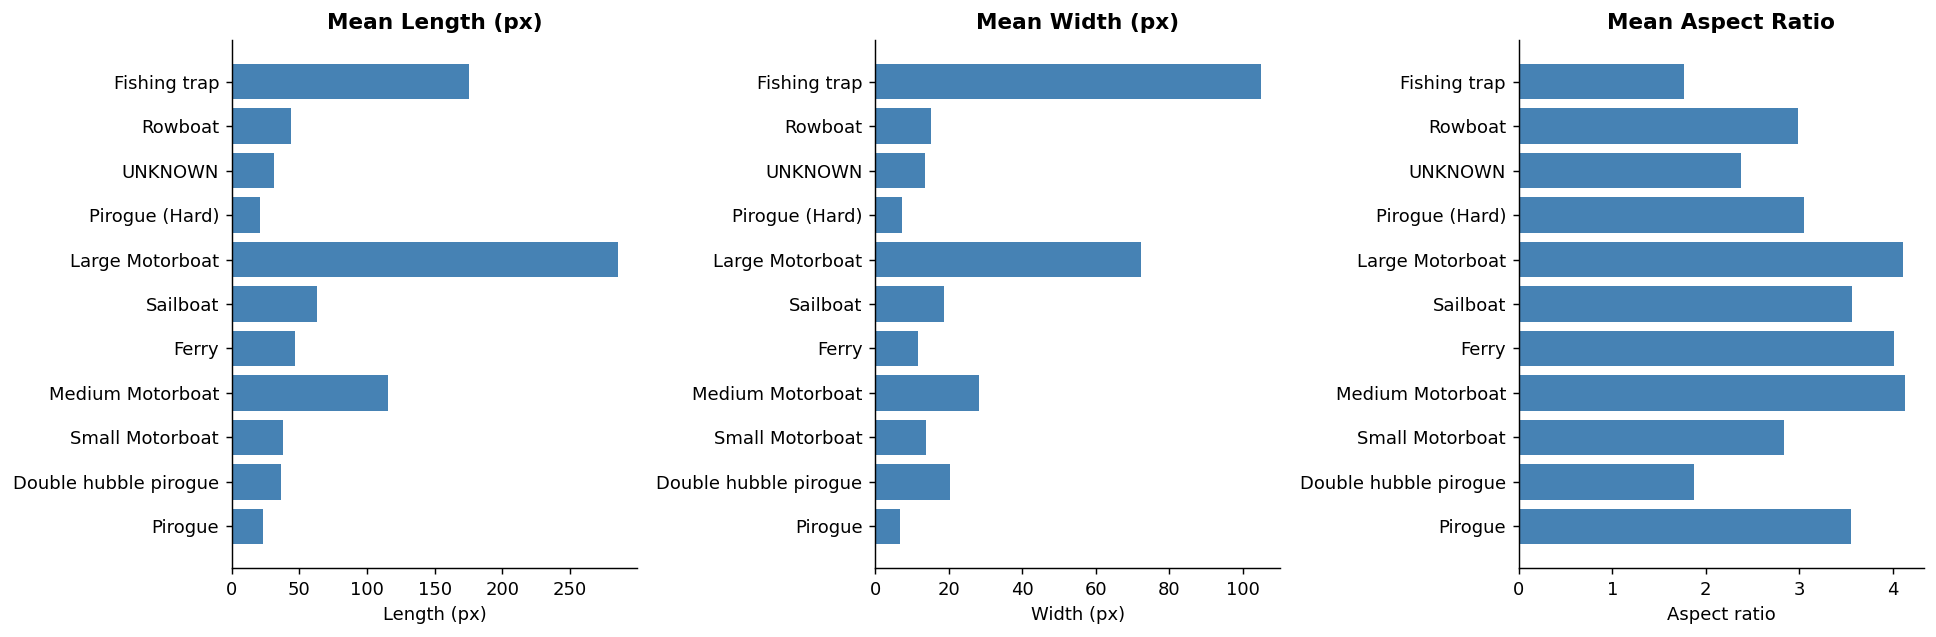

In [77]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from IPython.display import display, HTML

# 1. Known Resolution
RESOLUTION_M_PX = 0.3

def haversine(lon1, lat1, lon2, lat2):
    """Calculates the exact distance in meters between two coordinates."""
    R = 6371000  # Radius of Earth in meters
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

# Initialize storage
stats = defaultdict(lambda: {"l_px": [], "s_px": [], "l_m": [], "s_m": []})

# Scan GeoJSONs directly
for geo_path in DATA_ROOT.glob("*.geojson"):
    with open(geo_path, "r", encoding="utf-8") as f:
        data = json.load(f)
        
    for feature in data.get('features', []):
        props = feature.get('properties', {})
        cid = props.get('class_id', props.get('id', props.get('label')))
        
        if cid is None or int(cid) not in CLASS_NAMES:
            continue
            
        cid = int(cid)
        geom = feature.get('geometry', {})
        
        if geom.get('type') == 'Polygon':
            ring = geom['coordinates'][0]
            if len(ring) >= 4:
                x0, y0 = ring[0][0], ring[0][1]
                x1, y1 = ring[1][0], ring[1][1]
                x2, y2 = ring[2][0], ring[2][1]
                
                # Check if coordinates are Longitude/Latitude (Between -180 and +180)
                if abs(x0) <= 180 and abs(y0) <= 90:
                    # Calculate true meters using Haversine
                    s1_m = haversine(x0, y0, x1, y1)
                    s2_m = haversine(x1, y1, x2, y2)
                    
                    # Convert to true pixels using the known resolution
                    s1_px = s1_m / RESOLUTION_M_PX
                    s2_px = s2_m / RESOLUTION_M_PX
                else:
                    # Fallback: Coordinates are already in pixels
                    s1_px = np.hypot(x1 - x0, y1 - y0)
                    s2_px = np.hypot(x2 - x1, y2 - y1)
                    s1_m = s1_px * RESOLUTION_M_PX
                    s2_m = s2_px * RESOLUTION_M_PX
                
                stats[cid]["l_px"].append(max(s1_px, s2_px))
                stats[cid]["s_px"].append(min(s1_px, s2_px))
                stats[cid]["l_m"].append(max(s1_m, s2_m))
                stats[cid]["s_m"].append(min(s1_m, s2_m))

# Build exact DataFrame
rows = []
for cid, s in sorted(stats.items()):
    if not s["l_px"]:
        continue
    
    l_px_arr = np.array(s["l_px"])
    s_px_arr = np.array(s["s_px"])
    l_m_arr = np.array(s["l_m"])
    s_m_arr = np.array(s["s_m"])
    
    rows.append({
        "Class ID": cid,
        "Class": CLASS_NAMES[cid],
        "Count": len(l_px_arr),
        "Length (px)": round(np.mean(l_px_arr), 2),
        "Length (m)": round(np.mean(l_m_arr), 2),
        "Width (px)": round(np.mean(s_px_arr), 2),
        "Width (m)": round(np.mean(s_m_arr), 2),
        "Area (px^2)": round(np.mean(l_px_arr * s_px_arr), 2),
        "Aspect ratio": round(np.mean(l_px_arr / (s_px_arr + 1e-9)), 2)
    })

df_sizes = pd.DataFrame(rows)

# 2. Print clean academic table (No index line numbers)
print("OBB Geometric Statistics:")
print("=" * 105)
print(df_sizes.to_string(index=False))
print("=" * 105)

# 3. Render Visualization Metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col, title in zip(
    axes,
    ["Length (px)", "Width (px)", "Aspect ratio"],
    ["Mean Length (px)", "Mean Width (px)", "Mean Aspect Ratio"],
):
    if col in df_sizes.columns:
        ax.barh(df_sizes["Class"], df_sizes[col], color="steelblue")
        ax.set_xlabel(col)
        ax.set_title(title, fontweight="bold")
    else:
        ax.text(0.5, 0.5, f"Column '{col}' not found", ha='center', va='center')

plt.tight_layout()
plt.show()

## 5. Object Size Distribution (Meters)

Counts the number of objects per class falling into specific length categories: 0-2.5m, 2.5-8m, and 8-12m.
*Note: This relies on `rasterio` to fetch the spatial resolution of the GeoTIFF tiles. It assumes the CRS units of the tiles are in meters and evaluates the longest edge of the OBB.*

In [78]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# 1. Known Resolution
RESOLUTION_M_PX = 0.3

def haversine(lon1, lat1, lon2, lat2):
    """Calculates the exact distance in meters between two coordinates."""
    R = 6371000  # Radius of Earth in meters
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

# Define size bins for each meter up to 20m, plus a catch-all for >20m
bins = list(range(21)) + [float('inf')]
bin_labels = [f"{i} - {i+1}m" for i in range(20)] + ["> 20m"]

# Initialize a dictionary to store counts
size_counts = {cls_name: {bl: 0 for bl in bin_labels} for cls_name in CLASS_NAMES.values()}

# Scan GeoJSONs directly
for geo_path in DATA_ROOT.glob("*.geojson"):
    with open(geo_path, "r", encoding="utf-8") as f:
        data = json.load(f)
        
    for feature in data.get('features', []):
        props = feature.get('properties', {})
        cid = props.get('class_id', props.get('id', props.get('label')))
        
        if cid is None or int(cid) not in CLASS_NAMES:
            continue
            
        cid = int(cid)
        cls_name = CLASS_NAMES[cid]
        geom = feature.get('geometry', {})
        
        if geom.get('type') == 'Polygon':
            ring = geom['coordinates'][0]
            if len(ring) >= 4:
                x0, y0 = ring[0][0], ring[0][1]
                x1, y1 = ring[1][0], ring[1][1]
                x2, y2 = ring[2][0], ring[2][1]
                
                # Check if coordinates are Longitude/Latitude
                if abs(x0) <= 180 and abs(y0) <= 90:
                    s1_m = haversine(x0, y0, x1, y1)
                    s2_m = haversine(x1, y1, x2, y2)
                else:
                    # Fallback: Coordinates are in pixels
                    s1_m = np.hypot(x1 - x0, y1 - y0) * RESOLUTION_M_PX
                    s2_m = np.hypot(x2 - x1, y2 - y1) * RESOLUTION_M_PX
                
                longest_side_m = max(s1_m, s2_m)
                
                # Distribute into designated metric bins
                for i in range(len(bins)-1):
                    if bins[i] <= longest_side_m < bins[i+1]:
                        size_counts[cls_name][bin_labels[i]] += 1
                        break

# Package results into a structured DataFrame
df_size_meters = pd.DataFrame.from_dict(size_counts, orient='index')
df_size_meters.index.name = "Class"
df_size_meters = df_size_meters.reset_index()

# ---------------------------------------------------------
# VISUALIZATION 1: Professional Interactive Styled Table
# ---------------------------------------------------------
print("Object counts per size category (in meters):")
styled_table = (
    df_size_meters.style
    .hide(axis="index")  # Removes line numbers
    .background_gradient(cmap="Blues", subset=bin_labels)  # Adds color intensity
    .set_properties(**{
        'border': '1px solid #cccccc', # Adds grid lines
        'text-align': 'center',
        'padding': '6px'
    })
    .set_table_styles([{
        'selector': 'th',
        'props': [('border', '1px solid #cccccc'), ('background-color', '#f4f4f4'), ('text-align', 'center')]
    }])
)
display(styled_table)



Object counts per size category (in meters):


Class,0 - 1m,1 - 2m,2 - 3m,3 - 4m,4 - 5m,5 - 6m,6 - 7m,7 - 8m,8 - 9m,9 - 10m,10 - 11m,11 - 12m,12 - 13m,13 - 14m,14 - 15m,15 - 16m,16 - 17m,17 - 18m,18 - 19m,19 - 20m,> 20m
Pirogue,0,0,0,40,168,206,161,115,75,57,53,25,13,8,9,1,2,1,0,0,0
Double hubble pirogue,0,0,0,3,20,57,55,54,64,57,91,88,70,50,40,32,28,16,13,8,13
Small Motorboat,0,0,0,1,4,7,23,27,43,51,31,37,27,32,21,18,13,8,9,3,10
Medium Motorboat,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,2,1,0,3,7,101
Ferry,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
Sailboat,0,0,0,0,0,0,2,1,1,2,3,3,2,9,7,4,6,11,6,7,43
Large Motorboat,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,22
Pirogue (Hard),0,0,0,0,8,9,5,4,4,0,0,0,0,1,0,0,0,0,0,0,0
UNKNOWN,0,0,2,31,42,30,23,35,6,8,4,3,0,1,1,0,0,0,1,0,12
Rowboat,0,0,0,0,0,0,0,0,0,1,0,0,2,1,1,0,1,0,0,0,0


In [79]:
import json
import pandas as pd
import numpy as np

# 1. Known Resolution
RESOLUTION_M_PX = 0.3

def haversine(lon1, lat1, lon2, lat2):
    """Calculates the exact distance in meters between two coordinates."""
    R = 6371000  # Radius of Earth in meters
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

results = []

# Scan GeoJSONs directly
for geo_path in DATA_ROOT.glob("*.geojson"):
    small_object_count = 0
    
    with open(geo_path, "r", encoding="utf-8") as f:
        data = json.load(f)
        
    for feature in data.get('features', []):
        props = feature.get('properties', {})
        cid = props.get('class_id', props.get('id', props.get('label')))
        
        if cid is None or int(cid) not in CLASS_NAMES:
            continue
            
        geom = feature.get('geometry', {})
        
        if geom.get('type') == 'Polygon':
            ring = geom['coordinates'][0]
            if len(ring) >= 4:
                x0, y0 = ring[0][0], ring[0][1]
                x1, y1 = ring[1][0], ring[1][1]
                x2, y2 = ring[2][0], ring[2][1]
                
                # Check if coordinates are Longitude/Latitude
                if abs(x0) <= 180 and abs(y0) <= 90:
                    s1_m = haversine(x0, y0, x1, y1)
                    s2_m = haversine(x1, y1, x2, y2)
                else:
                    # Fallback: Coordinates are in pixels
                    s1_m = np.hypot(x1 - x0, y1 - y0) * RESOLUTION_M_PX
                    s2_m = np.hypot(x2 - x1, y2 - y1) * RESOLUTION_M_PX
                
                longest_side_m = max(s1_m, s2_m)
                
                # Check if the object's longest side is smaller than 4 meters
                if longest_side_m < 4.0:
                    small_object_count += 1
                    
    # Save the result for this specific image
    results.append({
        "Image (GeoJSON stem)": geo_path.stem, 
        "Objects < 4m": small_object_count
    })

# Format into a DataFrame and sort by the count (descending)
df_small_objects = pd.DataFrame(results).sort_values(by="Objects < 4m", ascending=False)

# Print a clean, index-free table
print("Images containing objects smaller than 4 meters:")
print("-" * 70)
print(df_small_objects.to_string(index=False))
print("-" * 70)


Images containing objects smaller than 4 meters:
----------------------------------------------------------------------
                                                   Image (GeoJSON stem)  Objects < 4m
IMG_PNEO3_STD_202411220658104_MS-FS_ORT_PWOI_000373576_1_2_F_1_RGB_R1C1            34
IMG_PNEO3_STD_202405300712136_MS-FS_ORT_PWOI_000373512_2_2_F_1_RGB_R1C1            12
   IMG_PNEO3_STD_202308070701158_PAN_ORT_PWOI_000373512_15_2_F_1_P_R2C1            10
    IMG_PNEO3_STD_202304300656161_MS-FS_ORT_PWOI_000373589_4_1_F_1_R1C2             9
    IMG_PNEO3_STD_202305170722489_PAN_ORT_PWOI_000373521_3_2_F_1_P_R4C1             5
                                                      Nosy_boraha_south             2
    IMG_PNEO4_STD_202310220710427_PAN_ORT_PWOI_000373568_2_1_F_1_P_R1C1             2
    IMG_PNEO3_STD_202405300711567_PAN_ORT_PWOI_000373512_3_1_F_1_P_R2C1             1
    IMG_PNEO3_STD_202304300656161_PAN_ORT_PWOI_000373589_4_1_F_1_P_R1C1             1
    IMG_PNEO3_STD_20

In [83]:
import json
import numpy as np
from pathlib import Path

def haversine(lon1, lat1, lon2, lat2):
    """Calculates the exact distance in meters between two coordinates."""
    R = 6371000  # Radius of Earth in meters
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

def update_small_objects(input_path, output_path):
    """
    Reads a GeoJSON, changes class_id from 0 or 1 to 8 
    if the object's longest side is < 4 meters, and saves the file.
    """
    with open(input_path, "r", encoding="utf-8") as f:
        data = json.load(f)
        
    modified_count = 0
        
    for feature in data.get('features', []):
        props = feature.get('properties', {})
        cid = props.get('class_id')
        
        # Only evaluate objects that are currently class 0 or 1
        if cid in [0, 1]:
            geom = feature.get('geometry', {})
            
            if geom.get('type') == 'Polygon':
                ring = geom['coordinates'][0]
                if len(ring) >= 4:
                    x0, y0 = ring[0][0], ring[0][1]
                    x1, y1 = ring[1][0], ring[1][1]
                    x2, y2 = ring[2][0], ring[2][1]
                    
                    # Calculate side lengths in meters
                    s1_m = haversine(x0, y0, x1, y1)
                    s2_m = haversine(x1, y1, x2, y2)
                    
                    longest_side_m = max(s1_m, s2_m)
                    
                    # If the object is smaller than 4m, update to class 8
                    if longest_side_m < 4.0:
                        feature['properties']['class_id'] = 8
                        modified_count += 1
                        
    # Save the updated GeoJSON
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(data, f, separators=(',', ':')) # Using separators saves space
        
    return modified_count


DATA_ROOT = Path("/home/thomas/Documents/code/pleiades-boat-detection/data/raw")
for geo_path in DATA_ROOT.glob("*.geojson"):
    # Overwriting the original file directly (make a backup first!)
    changed = update_small_objects(geo_path, geo_path)
    if changed > 0:
        print(f"Updated {changed} objects in {geo_path.name}")


Updated 1 objects in IMG_PNEO3_STD_202405300711567_PAN_ORT_PWOI_000373512_3_1_F_1_P_R2C1.geojson
Updated 2 objects in IMG_PNEO4_STD_202310220710427_PAN_ORT_PWOI_000373568_2_1_F_1_P_R1C1.geojson
Updated 5 objects in IMG_PNEO3_STD_202305170722489_PAN_ORT_PWOI_000373521_3_2_F_1_P_R4C1.geojson
Updated 1 objects in IMG_PNEO3_STD_202304300656161_PAN_ORT_PWOI_000373589_4_1_F_1_P_R1C1.geojson
Updated 1 objects in IMG_PNEO3_STD_202304300656161_MS-FS_ORT_PWOI_000373589_4_1_F_1_R1C2.geojson
Updated 1 objects in IMG_PNEO3_STD_202308070701158_PAN_ORT_PWOI_000373512_15_2_F_1_P_R2C1.geojson
Updated 20 objects in IMG_PNEO3_STD_202411220658104_MS-FS_ORT_PWOI_000373576_1_2_F_1_RGB_R1C1.geojson
Updated 1 objects in IMG_PNEO3_STD_202307020708006_PAN_ORT_PWOI_000373520_8_1_F_1_P_R1C2.geojson
Updated 11 objects in IMG_PNEO3_STD_202405300712136_MS-FS_ORT_PWOI_000373512_2_2_F_1_RGB_R1C1.geojson
